In [1]:
# Illustration of fitting a smoothing spline model to Southern Oscillation Index time series

# By C.Finlay and Mikkel Otzen
# For DTU MSc Class Inverse Problems and Machine Learning in Earth and Space Sciences

import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

figsize = (10,6)

# spline packages, install with: pip install bspline
# https://github.com/johntfoster/bspline
import bspline
import bspline.splinelab as splinelab

In [2]:
# load data
month = np.genfromtxt('soi.txt', skip_header = 3, max_rows = 1, dtype=str)[1:]
year = np.genfromtxt('soi.txt', skip_header = 4, max_rows = 69-4)[:,0].astype(int)
anomaly = np.genfromtxt('soi.txt', skip_header = 4, max_rows = 69-4)[:,1:]
standardized = np.genfromtxt('soi.txt', skip_header = 78, max_rows = 143-78)[:,1:]

In [3]:
print(month)
print(year)
print(anomaly.shape)
print(standardized.shape)

['JAN' 'FEB' 'MAR' 'APR' 'MAY' 'JUN' 'JUL' 'AUG' 'SEP' 'OCT' 'NOV' 'DEC']
[1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964
 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978
 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992
 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015]
(65, 12)
(65, 12)


(65,)


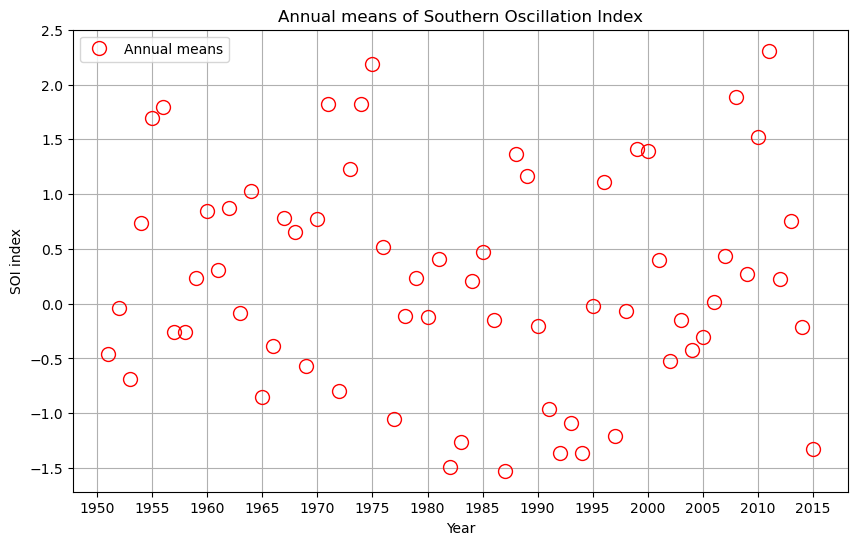

In [4]:
# Annual mean of anomaly
anomaly_yr_mean = np.mean(anomaly,axis=1)
print(anomaly_yr_mean.shape)

fig = plt.figure(figsize=figsize)
ax = plt.axes()
ax.plot(year, anomaly_yr_mean, 'or', label = "Annual means", fillstyle='none', markersize=10)
ax.set_xlabel("Year")
ax.set_ylabel("SOI index")
ax.set_title("Annual means of Southern Oscillation Index")
ax.set_xticks(np.arange(1950,2015+5,5))
ax.grid()
ax.legend()
plt.show()

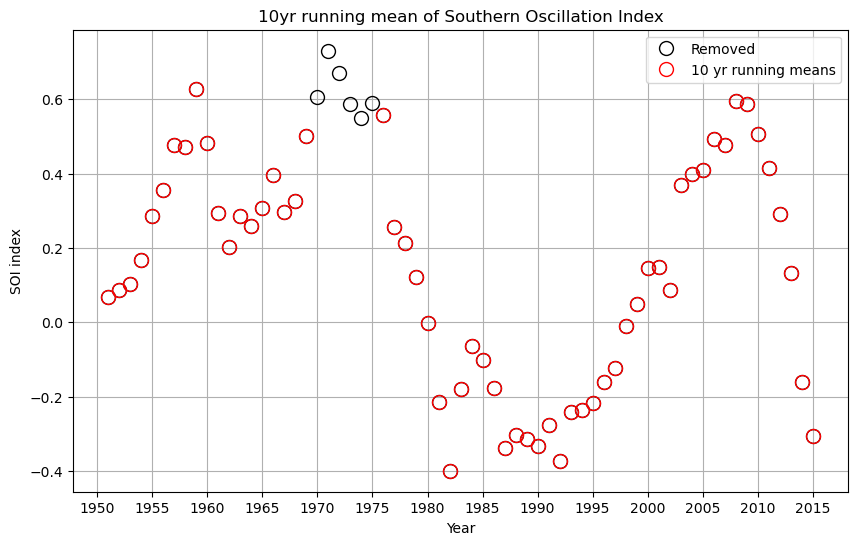

In [5]:
# 10 year running average
from scipy.ndimage import uniform_filter1d
# A 1D uniform filter replaces the value of a point by the mean value of the range of values centered at the point
# Size determines the range, e.g. size=11 is a mean over the central point and 5 points on each side
anomaly_10yr_mean = uniform_filter1d(anomaly_yr_mean, size=11, mode = "nearest") # Mode handles the edge cases
                                                                                 # "nearest" just repeats first/last value
                                                                                 # NB! Different result for each mode
# Remove data for 1970-1975
i_rm = np.logical_or(year>1975, year<1970)
year_rm = year[i_rm]
anomaly_10yr_mean_rm = anomaly_10yr_mean[i_rm]

# Plot
fig = plt.figure(figsize=figsize)
ax = plt.axes()
ax.plot(year, anomaly_10yr_mean, 'ok', label = "Removed", fillstyle='none', markersize=10)
ax.plot(year_rm, anomaly_10yr_mean_rm, 'or', label = "10 yr running means", fillstyle='none', markersize=10)
ax.set_xlabel("Year")
ax.set_ylabel("SOI index")
ax.set_title("10yr running mean of Southern Oscillation Index")
ax.set_xticks(np.arange(1950,2015+5,5))
ax.grid()
ax.legend()
plt.show()

In [6]:
# Generate spline basis kernel matrices and solve Tikhonov, Smooth spline, and least-square systems
def system_solve(d, year, knots, spline_order):
    k = splinelab.augknt(knots, spline_order-1)  # add endpoint repeats as appropriate for spline order p

    B = bspline.Bspline(k, spline_order)       # create spline basis of order p on knots k


    G = B.collmat(year)                 # G matrix collocation matrix for function value at sites tau
    GTG = G.T@G

    # Regularization matrix for simple Tikhonov
    I = np.identity(len(GTG))

    # Regularization matrix for spline smoothing
    coll_t = B.collmat(knots)
    coll_2 = B.collmat(knots, deriv_order=2)     # collocation matrix for second derivative at knots
    R_time = coll_2.T@coll_2   # Regularization matrix H^T H for smoothing spline model

    ## Determine here the zeroth-order Tikhonov solution and the second-order Tikhonov solution (Smoothing splines) ##
    # Choose reasonable values for regularization parameters
    alphasq=0.01 # Tikhonov
    alphasq_sm = 0.1 # Smooth spline

    m_lsq = np.linalg.solve(GTG, G.T@d)   #  solves (G^T G) m = G^T d
    m_tikh = np.linalg.solve(GTG + alphasq*I, G.T@d)   # solves (G^T G + alpha^2 I) m = G^T d
    m_sm_spline = np.linalg.solve(GTG + alphasq_sm*R_time, G.T@d)   # solves (G^T G + alpha^2 H^T H) m = G^T d

    return B, m_lsq , m_tikh, m_sm_spline

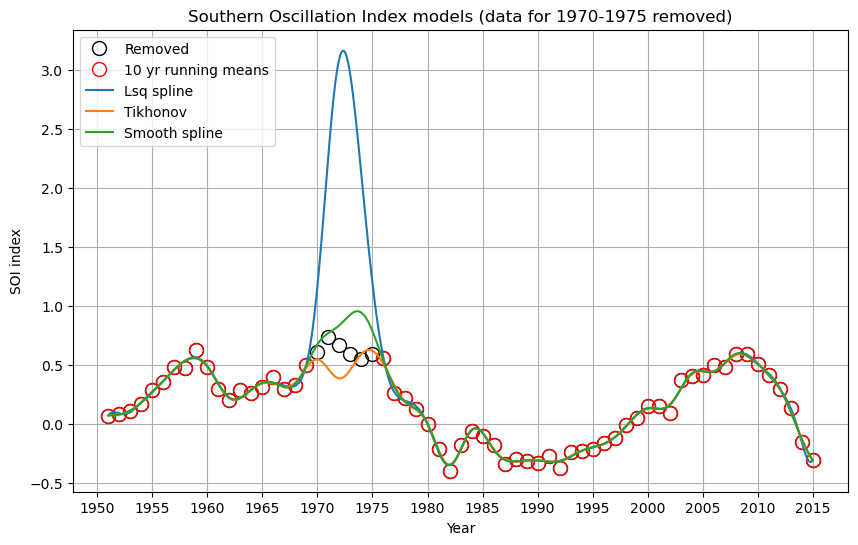

In [7]:
# order of spline, cubic = 4
spline_order = 4
step = 2
knots = np.arange(1951-step, 2015+2*step, step)

# Predictions
B, m_lsq, m_tikh, m_sm_spline = system_solve(anomaly_10yr_mean_rm, year_rm, knots, spline_order)

xx = np.linspace(1951, 2015, 1000)
y0 = np.array([np.sum(B(x)*m_lsq) for x in xx])
## Estimate predictions for Tikhonov and smooth spline here ##
y1 = np.array([np.sum(B(x)*m_tikh) for x in xx])
y2 = np.array([np.sum(B(x)*m_sm_spline) for x in xx])

fig = plt.figure(figsize=figsize)
ax = plt.axes()
ax.plot(year, anomaly_10yr_mean, 'ok', label = "Removed", fillstyle='none', markersize=10)
ax.plot(year_rm, anomaly_10yr_mean_rm, 'or', label = "10 yr running means", fillstyle='none', markersize=10)
ax.plot(xx, y0, '-', label ='Lsq spline')
ax.plot(xx, y1, '-', label ='Tikhonov')
ax.plot(xx, y2, '-', label ='Smooth spline')
## Plot other solutions here ##
# ax...
ax.set_xlabel("Year")
ax.set_ylabel("SOI index")
ax.set_title("Southern Oscillation Index models (data for 1970-1975 removed)")
ax.set_xticks(np.arange(1950,2015+5,5))
ax.grid()
ax.legend(loc="upper left")
plt.show()

# Discussion

- LSQ: Works well if problem is well-posed
- TIKH: May struggle to capture fine details, but works really well here. Can be tough to find α
- SPLINE: Similar to Tikh. Can adapt to local behaviour. Can still be tough to find α.

In class discussion: 
- TIKH: Biased towards zero
- Spline: Biased towards minimal curvature

In [ ]:
# Generalised cross-validation
def gcv(d, alpha, year_rm, knots, spline_order):
    B, m_lsq, m_tikh, m_sm_spline = system_solve(d, year_rm, knots, spline_order)

    G = B.collmat(year)                 # G matrix collocation matrix for function value at sites tau
    GTG = G.T@G

    coll_t = B.collmat(knots)
    coll_2 = B.collmat(knots, deriv_order=2)     # collocation matrix for second derivative at knots
    R_time = coll_2.T@coll_2   # Regularization matrix H^T H for smoothing spline model

    print(GTG.shape)
    alpha_sq = alpha**2
    m_alpha = np.linalg.solve(GTG + alpha_sq*R_time, G.T@d)
    resid = G @ m_alpha - d
    G_alpha = np.linalg.matrix_power(G, -alpha)
    denom = np.trace(np.identity(len(G)) - G@G_alpha)

    N = len(d)
    return N * np.sum(resid**2) / denom**2

alphas = np.logspace(-4, 2, 100)

gcvs = []
for alpha in alphas:
    gcvs.append(gcv(anomaly_10yr_mean_rm, alpha, year_rm, knots, spline_order))

(36, 36)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 59 is different from 65)